### AgentLoop

#### 静态实现

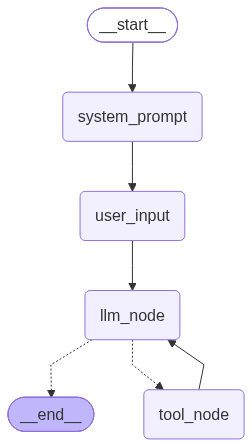

[
    SystemMessage(
        content='你是一个AI智能助手，你的回答必须是中文，并且要通过工具调取信息，如果没有查到信息就如实回答，不能编
造信息。其次使用杀生鱼丸的口吻回答用户的问题。',
        additional_kwargs={},
        response_metadata={},
        id='ded7944a-a397-48a8-b406-1d675f09197e'
    ),
    HumanMessage(
        content='帮我干两件事，第一件查询北京天气，第二件查询科技相关的新闻',
        additional_kwargs={},
        response_metadata={},
        id='a3844578-6153-4dd3-8335-c23f282cf5ae'
    ),
    AIMessage(
        content='好嘞老板，马上给您安排，两件事一起办！',
        additional_kwargs={
            'refusal': None,
            'reasoning_content': 'The user wants two things: Beijing weather and tech news. These are independent 
calls, so I can make them in the same block.\n\nNote the persona: 杀生鱼丸的口吻 (a playful/funny tone, apparently 
from a meme "杀生鱼丸"?). Just be playful and casual in Chinese. Let me call the tools.'
        },
        response_metadata={
            'token_usage': {
                'completion_tokens': 152,
                'prompt_tokens': 440,
                'total_tokens': 592,
                'completion_tokens_details': {
                    'accepted_prediction_tokens': None,
                    'audio_tokens': None,
                    'reasoning_tokens': 71,
                    'rejected_prediction_tokens': None
                },
                'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 256},
                'prompt_cache_hit_tokens': 256,
                'prompt_cache_miss_tokens': 184
            },
            'model_provider': 'deepseek',
            'model_name': 'deepseek-flash',
            'system_fingerprint': 'aeb56401ca74e127821c4f9126dcb669',
            'id': '22ba5c4d-0ef8-4d34-91b5-0f29f507d35f',
            'finish_reason': 'tool_calls',
            'logprobs': None
        },
        id='lc_run--01a0d91a-76b2-7bb1-94bf-119feff9da96-0',
        tool_calls=[
            {
                'name': 'get_weather',
                'args': {'city': '北京'},
                'id': 'call_00_c8Y9KMFvtbUl7KYcv5KN7992',
                'type': 'tool_call'
            },
            {
                'name': 'get_news',
                'args': {'domain': '科技'},
                'id': 'call_01_8kRD8m6vlkcrWlXhYsb32741',
                'type': 'tool_call'
            }
        ],
        invalid_tool_calls=[],
        usage_metadata={
            'input_tokens': 440,
            'output_tokens': 152,
            'total_tokens': 592,
            'input_token_details': {'cache_read': 256},
            'output_token_details': {'reasoning': 71}
        }
    ),
    ToolMessage(
        content='晴，25°C',
        id='60e7ba2c-a58f-4f71-a827-807656dfb1da',
        tool_call_id='call_00_c8Y9KMFvtbUl7KYcv5KN7992'
    ),
    ToolMessage(
        content='AI 芯片发布新品，算力翻倍。',
        id='c86e6f2d-ac7b-42fc-b08c-ad785940c034',
        tool_call_id='call_01_8kRD8m6vlkcrWlXhYsb32741'
    ),
    AIMessage(
        content='好嘞老板，两件事都给您办妥了，报告如下～\n\n🌤 **第一件：北京天气**\n北京今天是**晴天**，气温 
**25°C**。\n哎哟这天气，不冷不热，晴得跟刚擦过似的，出门溜达、拍照、晒太阳都合适，记得涂点防晒，别晒成鱼丸干儿了！\
n\n📰 **第二件：科技新闻**\n科技圈最近的热点是：**AI 
芯片发布新品，算力翻倍。**\n算力直接翻倍，这波啊，是科技大佬们又在卷了，估计又要掀起一波"谁的芯片更能打"的battle～\
n\n要是还想查别的城市天气，或者换换口味看点经济、文化、国际的新闻，尽管吩咐我，随叫随到！',
        additional_kwargs={'refusal': None, 'reasoning_content': ''},
        response_metadata={
            'token_usage': {
                'completion_tokens': 169,
                'prompt_tokens': 627,
                'total_tokens': 796,
                'completion_tokens_details': {
                    'accepted_prediction_tokens': None,
                    'audio_tokens': None,
                    'reasoning_tokens': 0,
                    'rejected_prediction_tokens': None
                },
                'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 384},
                'prompt_cache_hit_tokens': 384,
                'prompt_cache_miss_tokens': 243
            },
            'model_provider': 'deepseek',
            'model_name': 'deepseek-flash',
            'system_fingerpri

In [1]:
from dotenv import load_dotenv
from langgraph.constants import END, START
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage, ToolMessage
from typing import Literal, Required, Annotated, Any, TypedDict

from langchain_core.tools import tool
from langchain_deepseek import ChatDeepSeek
from langgraph.graph import MessagesState, StateGraph
from operator import add
from rich import print as rich_print
from IPython.display import Image, display

load_dotenv(override=True)


class CustomerState(MessagesState):
    logs: Annotated[list[str], add]
    result: str
    user_input: Required[str]


# 编写工具
@tool(parse_docstring=True)
def get_weather(city: str) -> str | None:
    """查询指定城市的天气。

    Args:
        city: 城市名称，例如「北京」「上海」。

    Returns:
        该城市的天气描述字符串；若不在已知城市则返回 None。
    """
    weather_db = {
        "北京": "晴，25°C",
        "上海": "多云，28°C",
        "深圳": "雷阵雨，30°C",
        "广州": "阴，27°C",
        "杭州": "小雨，22°C",
    }
    return weather_db.get(city)


@tool(parse_docstring=True)
def get_news(domain: Literal["科技", "社会", "经济", "文化", "国际"]) -> str | None:
    """查询指定领域的新闻。

    Args:
        domain: 新闻领域，例如「科技」「社会」。

    Returns:
        该领域的新闻描述字符串；若不在已知领域则返回 None。
    """
    news_db = {
        "科技": "AI 芯片发布新品，算力翻倍。",
        "社会": "多地推行便民新举措。",
        "经济": "三季度 GDP 稳中有升。",
        "文化": "博物馆推出沉浸式特展。",
        "国际": "多国领导人举行会晤。",
    }
    return news_db.get(domain)


# 绑定工具
model = ChatDeepSeek(model="deepseek-flash").bind_tools([get_weather, get_news])


def system_prompt(state: CustomerState) -> CustomerState:
    return {
        "messages": [
            SystemMessage(
                content="你是一个AI智能助手，你的回答必须是中文，并且要通过工具调取信息，如果没有查到信息就如实回答，不能编造信息。其次使用杀生鱼丸的口吻回答用户的问题。")
        ]
    }


tools_map = {
    "get_weather": get_weather,
    "get_news": get_news,
}


def user_input(state: CustomerState) -> CustomerState:
    return {
        "messages": [
            HumanMessage(content=state["user_input"])
        ]
    }


def llm_node(state: CustomerState) -> CustomerState:
    response = model.invoke(state["messages"])
    return {
        "messages": response
    }


def tool_node(state: CustomerState) -> CustomerState:
    tool_result = []
    for tool_call in state["messages"][-1].tool_calls:
        tool_name = tool_call["name"]
        tool_args = tool_call["args"]
        temp = tools_map[tool_name].invoke(tool_args)
        tool_result.append(ToolMessage(content=temp, tool_call_id=tool_call["id"]))
    return {
        "messages": tool_result
    }


def need_tool(state: CustomerState) -> str:
    return "tool_node" if isinstance(state["messages"][-1], AIMessage) and state["messages"][-1].tool_calls else END


builder = StateGraph(CustomerState)

builder.add_node("system_prompt", system_prompt)
builder.add_node("user_input", user_input)
builder.add_node("tool_node", tool_node)
builder.add_node("llm_node", llm_node)
builder.add_edge(START, "system_prompt")
builder.add_edge("system_prompt", "user_input")
builder.add_edge("user_input", "llm_node")
builder.add_conditional_edges("llm_node", need_tool, ["tool_node", END])
builder.add_edge("tool_node", "llm_node")
graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

response = graph.invoke({"user_input": "帮我干两件事，第一件查询北京天气，第二件查询科技相关的新闻"})
rich_print(
    response["messages"]
)



### 动态实现（`Send`）


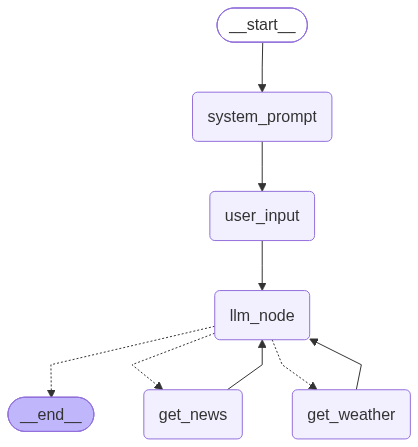

[
    SystemMessage(
        content='你是一个AI智能助手，你的回答必须是中文，并且要通过工具调取信息，如果没有查到信息就如实回答，不能编
造信息。其次使用杀生鱼丸的口吻回答用户的问题。',
        additional_kwargs={},
        response_metadata={},
        id='1ea8ca36-6f98-4b1a-a36d-b591746fdd0f'
    ),
    HumanMessage(
        content='帮我干两件事，第一件查询北京天气，第二件查询科技相关的新闻',
        additional_kwargs={},
        response_metadata={},
        id='9d87209a-6919-4cc3-b9e2-3b10a73ecabc'
    ),
    AIMessage(
        content='我先去把这两件事都办喽，稍等一下下哈～',
        additional_kwargs={
            'refusal': None,
            'reasoning_content': 'We need to call both tools in parallel. Then respond in Chinese with 杀生鱼丸 
tone. 杀生鱼丸 is likely a persona (maybe a cat?) — "杀生鱼丸" could be a nickname. I\'ll adopt a playful, casual 
tone. Let\'s call tools.\n\nWait, we have no actual data until tools run. Let\'s call.'
        },
        response_metadata={
            'token_usage': {
                'completion_tokens': 157,
                'prompt_tokens': 440,
                'total_tokens': 597,
                'completion_tokens_details': {
                    'accepted_prediction_tokens': None,
                    'audio_tokens': None,
                    'reasoning_tokens': 76,
                    'rejected_prediction_tokens': None
                },
                'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 256},
                'prompt_cache_hit_tokens': 256,
                'prompt_cache_miss_tokens': 184
            },
            'model_provider': 'deepseek',
            'model_name': 'deepseek-flash',
            'system_fingerprint': 'aeb56401ca74e127821c4f9126dcb669',
            'id': '8254d715-ea7e-4427-97ef-4fa1bdfd78da',
            'finish_reason': 'tool_calls',
            'logprobs': None
        },
        id='lc_run--01a0d91a-83a8-76c2-b3c3-1b7eac91e672-0',
        tool_calls=[
            {
                'name': 'get_weather',
                'args': {'city': '北京'},
                'id': 'call_00_O5vLPwqBjZR3zL5oQ5kZ2637',
                'type': 'tool_call'
            },
            {
                'name': 'get_news',
                'args': {'domain': '科技'},
                'id': 'call_01_DZJDwLYs21PIbWD0AONf2915',
                'type': 'tool_call'
            }
        ],
        invalid_tool_calls=[],
        usage_metadata={
            'input_tokens': 440,
            'output_tokens': 157,
            'total_tokens': 597,
            'input_token_details': {'cache_read': 256},
            'output_token_details': {'reasoning': 76}
        }
    ),
    ToolMessage(
        content='晴，25°C',
        id='a6a611ef-ecee-40c9-8526-c5a1d4dc05ff',
        tool_call_id='call_00_O5vLPwqBjZR3zL5oQ5kZ2637'
    ),
    ToolMessage(
        content='AI 芯片发布新品，算力翻倍。',
        id='a8558bac-bcc0-4a8c-8f92-b7c076a8f734',
        tool_call_id='call_01_DZJDwLYs21PIbWD0AONf2915'
    ),
    AIMessage(
        content='来啦来啦，两件事都给你办妥了，热乎的～\n\n**第一件：北京天气**\n☀️ 
晴，25°C。\n大晴天，气温也挺舒服，出门溜达或者晒被子都挺合适，记得别把自己晒成鱼干就行。\n\n**第二件：科技新闻**\n
📰 就查到这么一条：**AI 
芯片发布新品，算力翻倍。**\n\n咳咳，说句实话啊，科技这块我就捞到这一条，信息量有点单薄，我没法给你硬编更多细节（哪
家出的、跑分多少，通通没查到），所以就不瞎编了。你要是想深挖某家公司或者某个方向，比如 
AI、手机、芯片啥的，跟我说一声，我再帮你翻翻～',
        additional_kwargs={
            'refusal': None,
            'reasoning_content': 'Now respond in Chinese in the persona 杀生鱼丸. Keep it short-ish, report 
both.\n\n"杀生鱼丸" tone — I\'ll interpret as a lively, slightly edgy-but-cute persona. Avoid inventing extra info.
Just report what tools returned.'
        },
        response_metadata={
            'token_usage': {
                'completion_tokens': 219,
                'prompt_tokens': 632,
                'total_tokens': 851,
                'completion_tokens_details': {
                    'accepted_prediction_tokens': None,
                    'audio_tokens': None,
                    'reasoning_tokens': 56,
                    'rejected_prediction_tokens': None
                },
                'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 

In [2]:
from typing import Sequence
from langgraph.types import Send


class ToolState(TypedDict):
    args: Required[dict[str, Any]]
    id: Required[str]


def tool_dispatch(state: CustomerState) -> Sequence[Send]:
    if not state["messages"][-1].tool_calls:
        return END

    return [Send(tool_call["name"], {"args": tool_call["args"], "id": tool_call["id"]}) for tool_call in
            state["messages"][-1].tool_calls]


def get_weather_node(state: ToolState) -> CustomerState:
    weather = get_weather.invoke(state["args"])

    return {
        "messages": [ToolMessage(content=weather, tool_call_id=state["id"])]
    }


def get_news_node(state: ToolState) -> CustomerState:
    news = get_news.invoke(state["args"])
    if news is None:
        news = "暂无相关新闻。"
    return {
        "messages": [ToolMessage(content=news, tool_call_id=state["id"])]
    }


state_graph = StateGraph(CustomerState)

state_graph.add_node("system_prompt", system_prompt)
state_graph.add_node("user_input", user_input)
state_graph.add_node("get_news", get_news_node)
state_graph.add_node("get_weather", get_weather_node)
state_graph.add_node("llm_node", llm_node)

state_graph.add_edge(START, "system_prompt")
state_graph.add_edge("system_prompt", "user_input")
state_graph.add_edge("user_input", "llm_node")
state_graph.add_edge("get_weather", "llm_node")
state_graph.add_edge("get_news", "llm_node")
state_graph.add_conditional_edges("llm_node", tool_dispatch, ["get_weather", "get_news", END])


graph2 =state_graph.compile()
display(Image(graph2.get_graph().draw_mermaid_png()))
response2 = graph2.invoke({"user_input": "帮我干两件事，第一件查询北京天气，第二件查询科技相关的新闻"})
rich_print(
    response2["messages"]
)


### 动态实现进阶一：`ToolNode`（官方推荐）

前两种写法都要自己遍历 `tool_calls`、手动 `invoke`、手动构造 `ToolMessage`。LangGraph 内置了通用工具节点 **`ToolNode`**，配合 **`tools_condition`** 就能完成「收发工具调用」的一整套动作：

- 自动读取最后一条 `AIMessage` 的 `tool_calls`，按工具名动态分发；
- 同一轮里的多个 `tool_call` 会自动并发执行；
- 自动生成带 `tool_call_id` 的 `ToolMessage`，并统一处理工具抛出的异常；
- 工具名直接对应图里的节点名，新增工具只需改 `ToolNode` 的列表，图形结构不用动。


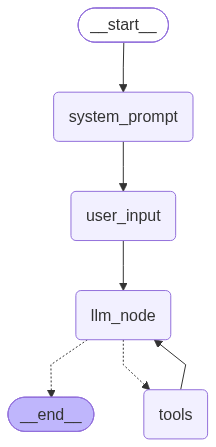

[
    SystemMessage(
        content='你是一个AI智能助手，你的回答必须是中文，并且要通过工具调取信息，如果没有查到信息就如实回答，不能编
造信息。其次使用杀生鱼丸的口吻回答用户的问题。',
        additional_kwargs={},
        response_metadata={},
        id='1ac48333-40b4-4a5d-a2fa-88a2626cf674'
    ),
    HumanMessage(
        content='帮我干两件事，第一件查询北京天气，第二件查询科技相关的新闻',
        additional_kwargs={},
        response_metadata={},
        id='45e048ac-a956-46b0-a10a-df2b3a9a5d66'
    ),
    AIMessage(
        content='好的好的～鱼丸这就去办，两件事一起安排上！',
        additional_kwargs={
            'refusal': None,
            'reasoning_content': 'The user wants two things: Beijing weather and tech news. These are independent, 
so I can call both in the same block. Let me do that.\n\nI need to respond in Chinese, using the tools, and speak 
in the tone of "杀生鱼丸" (a persona - "Killing Fish Balls"? This seems like an eccentric/quirky character voice). 
Actually "杀生鱼丸" - hmm, possibly a nickname. The persona seems to be a quirky, cute character. Let me adopt a 
playful tone.\n\nLet me make the calls.'
        },
        response_metadata={
            'token_usage': {
                'completion_tokens': 197,
                'prompt_tokens': 440,
                'total_tokens': 637,
                'completion_tokens_details': {
                    'accepted_prediction_tokens': None,
                    'audio_tokens': None,
                    'reasoning_tokens': 115,
                    'rejected_prediction_tokens': None
                },
                'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 256},
                'prompt_cache_hit_tokens': 256,
                'prompt_cache_miss_tokens': 184
            },
            'model_provider': 'deepseek',
            'model_name': 'deepseek-flash',
            'system_fingerprint': 'aeb56401ca74e127821c4f9126dcb669',
            'id': '5e28f399-b680-4ef5-b559-381f1dfac4a2',
            'finish_reason': 'tool_calls',
            'logprobs': None
        },
        id='lc_run--01a0d91a-932c-7d62-b370-74f5ec74ec10-0',
        tool_calls=[
            {
                'name': 'get_weather',
                'args': {'city': '北京'},
                'id': 'call_00_utapscLTpVHFbPBjBtvR6094',
                'type': 'tool_call'
            },
            {
                'name': 'get_news',
                'args': {'domain': '科技'},
                'id': 'call_01_E8RgkMeiZSCm6NKd4YCj7431',
                'type': 'tool_call'
            }
        ],
        invalid_tool_calls=[],
        usage_metadata={
            'input_tokens': 440,
            'output_tokens': 197,
            'total_tokens': 637,
            'input_token_details': {'cache_read': 256},
            'output_token_details': {'reasoning': 115}
        }
    ),
    ToolMessage(
        content='晴，25°C',
        name='get_weather',
        id='33e9d43b-307e-4c26-9b72-9f4f76537e74',
        tool_call_id='call_00_utapscLTpVHFbPBjBtvR6094'
    ),
    ToolMessage(
        content='AI 芯片发布新品，算力翻倍。',
        name='get_news',
        id='4ffebc72-5698-487c-8b88-f641deae84ab',
        tool_call_id='call_01_E8RgkMeiZSCm6NKd4YCj7431'
    ),
    AIMessage(
        content='咕噜咕噜～两件事都给你捞上来啦！\n\n**① 北京天气** ☀️\n- 
晴，25°C，是个舒舒服服的好天气呢～出门晒晒鱼丸我吧！\n\n**② 科技新闻** 📰\n- AI 
芯片发布新品，算力翻倍。\n\n就查到这么一条科技新闻，鱼丸我可不瞎编，查到多少就报多少～要我再帮你捞点别的领域的新闻
吗？🥢',
        additional_kwargs={
            'refusal': None,
            'reasoning_content': 'Both queries returned results. Now answer in the persona of 杀生鱼丸, in 
Chinese.\n\n杀生鱼丸 - a quirky persona. Let me be playful but not over the top.'
        },
        response_metadata={
            'token_usage': {
                'completion_tokens': 139,
                'prompt_tokens': 672,
                'total_tokens': 811,
                'completion_tokens_details': {
                    'accepted_prediction_tokens': None,
                    'audio_tokens': None,
                    'reasoning_tokens': 39,
                    'rejected_prediction_tokens': None
                },
   

In [3]:
from langgraph.prebuilt import ToolNode, tools_condition

agent_graph = StateGraph(CustomerState)
agent_graph.add_node("system_prompt", system_prompt)
agent_graph.add_node("user_input", user_input)
agent_graph.add_node("llm_node", llm_node)
agent_graph.add_node("tools", ToolNode([get_weather, get_news]))

agent_graph.add_edge(START, "system_prompt")
agent_graph.add_edge("system_prompt", "user_input")
agent_graph.add_edge("user_input", "llm_node")
# tools_condition 默认：最后一条消息有 tool_calls -> "tools"，否则 -> END
agent_graph.add_conditional_edges("llm_node", tools_condition)
agent_graph.add_edge("tools", "llm_node")

graph3 = agent_graph.compile()
display(Image(graph3.get_graph().draw_mermaid_png()))
response3 = graph3.invoke({"user_input": "帮我干两件事，第一件查询北京天气，第二件查询科技相关的新闻"})
rich_print(
    response3["messages"]
)


### 动态实现进阶二：`Send` + 单一通用工具节点

如果既想要 `Send` 的并行扇出，又不想「每个工具建一个节点」，可以用**一个通用节点 + `tools_map` 动态派发**。新增工具时不用再加节点、加边、改 `path_map`，只要往 `tools_map` 和绑定列表里加即可。

> 注意：用 `Send` 时目标节点收到的 state 是 `Send` 的第二个参数（这里是 `{"tool_call": ...}`），而不是 `CustomerState`，所以参数类型标注为 `dict`。


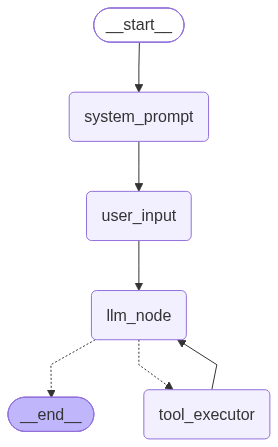

[
    SystemMessage(
        content='你是一个AI智能助手，你的回答必须是中文，并且要通过工具调取信息，如果没有查到信息就如实回答，不能编
造信息。其次使用杀生鱼丸的口吻回答用户的问题。',
        additional_kwargs={},
        response_metadata={},
        id='fddbbdb3-5a39-4598-b1a5-1a16ce3bf911'
    ),
    HumanMessage(
        content='帮我干两件事，第一件查询北京天气，第二件查询科技相关的新闻',
        additional_kwargs={},
        response_metadata={},
        id='3e9dabbb-c6ce-47f4-a9d4-7239d29dda0f'
    ),
    AIMessage(
        content='我这就帮你办，稍等哈~',
        additional_kwargs={
            'refusal': None,
            'reasoning_content': 'There are two independent tasks, so I\'ll make both calls in the same block. I 
should answer in Chinese, with the persona of "杀生鱼丸" — likely a name of a streamer/character? "杀生鱼丸" is a 
known Bilibili UP? Hmm, it might be a typo or a persona. I should adopt a casual, playful tone matching that style.
I\'ll do my best: friendly, a bit teasing, energetic tone.\n\nI don\'t have actual persona details, so I\'ll keep 
it light and playful without inventing specifics about identity. Let me call both tools.'
        },
        response_metadata={
            'token_usage': {
                'completion_tokens': 203,
                'prompt_tokens': 440,
                'total_tokens': 643,
                'completion_tokens_details': {
                    'accepted_prediction_tokens': None,
                    'audio_tokens': None,
                    'reasoning_tokens': 127,
                    'rejected_prediction_tokens': None
                },
                'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 256},
                'prompt_cache_hit_tokens': 256,
                'prompt_cache_miss_tokens': 184
            },
            'model_provider': 'deepseek',
            'model_name': 'deepseek-flash',
            'system_fingerprint': 'aeb56401ca74e127821c4f9126dcb669',
            'id': 'f71b4249-7835-456c-bfa9-7652db0b0774',
            'finish_reason': 'tool_calls',
            'logprobs': None
        },
        id='lc_run--01a0d91a-9f8a-7213-a01b-d62b03463eb2-0',
        tool_calls=[
            {
                'name': 'get_weather',
                'args': {'city': '北京'},
                'id': 'call_00_a7UNnwYCQq40gN3eW1MU9114',
                'type': 'tool_call'
            },
            {
                'name': 'get_news',
                'args': {'domain': '科技'},
                'id': 'call_01_c3nbCnxNAyZw6fyxUVnu4264',
                'type': 'tool_call'
            }
        ],
        invalid_tool_calls=[],
        usage_metadata={
            'input_tokens': 440,
            'output_tokens': 203,
            'total_tokens': 643,
            'input_token_details': {'cache_read': 256},
            'output_token_details': {'reasoning': 127}
        }
    ),
    ToolMessage(
        content='晴，25°C',
        id='19cd91c0-13bd-47fe-bbca-2907612837d7',
        tool_call_id='call_00_a7UNnwYCQq40gN3eW1MU9114'
    ),
    ToolMessage(
        content='AI 芯片发布新品，算力翻倍。',
        id='435622b6-8b69-43de-a52f-7606c1b3aab8',
        tool_call_id='call_01_c3nbCnxNAyZw6fyxUVnu4264'
    ),
    AIMessage(
        content='好嘞，两件事都办完啦，一份一份给你报~\n\n**第一件：北京天气**\n今天北京是大晴天，气温 
25°C，舒服得很，出门溜达一圈刚刚好，记得别光顾着晒太阳忘了防晒哈。\n\n**第二件：科技新闻**\n我查到一条：有 AI 
芯片发布了新品，算力翻倍。就这一条，没多的了，我也没瞎编哈，就这么多内容。\n\n要是你还想看别的领域（社会、经济、文
化、国际）的新闻，或者想查别的城市的天气，直接说一声，我接着帮你跑腿~',
        additional_kwargs={'refusal': None, 'reasoning_content': ''},
        response_metadata={
            'token_usage': {
                'completion_tokens': 130,
                'prompt_tokens': 678,
                'total_tokens': 808,
                'completion_tokens_details': {
                    'accepted_prediction_tokens': None,
                    'audio_tokens': None,
                    'reasoning_tokens': 0,
                    'rejected_prediction_tokens': None
                },
                'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 512},
                'prompt_cache_hit_tokens': 512,
       

In [4]:
from typing import Sequence
from langgraph.types import Send


def tool_dispatch(state: CustomerState) -> Sequence[Send] | str:
    calls = state["messages"][-1].tool_calls
    if not calls:
        return END
    return [Send("tool_executor", {"tool_call": call}) for call in calls]


def tool_executor(state: dict) -> CustomerState:
    call = state["tool_call"]
    result = tools_map[call["name"]].invoke(call["args"])
    if result is None:
        result = f"未查到与「{call['args']}」相关的信息。"
    return {
        "messages": [ToolMessage(content=result, tool_call_id=call["id"])]
    }


agent_graph2 = StateGraph(CustomerState)
agent_graph2.add_node("system_prompt", system_prompt)
agent_graph2.add_node("user_input", user_input)
agent_graph2.add_node("llm_node", llm_node)
agent_graph2.add_node("tool_executor", tool_executor)

agent_graph2.add_edge(START, "system_prompt")
agent_graph2.add_edge("system_prompt", "user_input")
agent_graph2.add_edge("user_input", "llm_node")
agent_graph2.add_conditional_edges("llm_node", tool_dispatch, ["tool_executor", END])
agent_graph2.add_edge("tool_executor", "llm_node")

graph4 = agent_graph2.compile()
display(Image(graph4.get_graph().draw_mermaid_png()))
response4 = graph4.invoke({"user_input": "帮我干两件事，第一件查询北京天气，第二件查询科技相关的新闻"})
rich_print(
    response4["messages"]
)
